In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
df = pd.read_csv(
    "ncr_ride_bookings.csv",
    sep=",",
    quotechar='"',
    encoding="utf-8"
)

print(df.columns.tolist())

['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']


In [3]:
# Supprime les espaces au début et à la fin des noms de colonnes
df.columns = df.columns.str.strip()

In [4]:
# Sélection des colonnes de type chaîne
string_cols = df.select_dtypes(include="object").columns

# Suppression des espaces en début et fin de chaque valeur
df[string_cols] = df[string_cols].apply(lambda col: col.str.strip())

C:\Users\Data404\AppData\Local\Temp\ipykernel_11636\1642286837.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include="object").columns


In [5]:
id_cols = ["Booking ID", "Customer ID"]

for col in id_cols:
    df[col] = df[col].str.replace('"', '', regex=False).str.strip()

In [8]:
df.info()
df

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,CNR6500631,Completed,CID4337371,Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,CNR2468611,Completed,CID2325623,Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,CNR6358306,Completed,CID9925486,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,CNR3030099,Completed,CID9415487,Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [7]:
booking_cols = [
    "Booking ID",
    "Date",
    "Time",
    "Booking Status",
    "Customer ID",
    "Vehicle Type"
]

ride_cols = [
    "Booking ID",
    "Pickup Location",
    "Drop Location",
    "Ride Distance",
    "Booking Value",
    "Payment Method"
]

performance_cols = [
    "Booking ID",
    "Avg VTAT",
    "Avg CTAT",
    "Driver Ratings",
    "Customer Rating",
    "Cancelled Rides by Customer",
    "Cancelled Rides by Driver",
    "Incomplete Rides"
]

df_booking = df[booking_cols]

df_ride = df[ride_cols]

df_performance = df[performance_cols]
print(df_booking.head())


   Booking ID        Date      Time   Booking Status Customer ID  \
0  CNR5884300  2024-03-23  12:29:38  No Driver Found  CID1982111   
1  CNR1326809  2024-11-29  18:01:39       Incomplete  CID4604802   
2  CNR8494506  2024-08-23  08:56:10        Completed  CID9202816   
3  CNR8906825  2024-10-21  17:17:25        Completed  CID2610914   
4  CNR1950162  2024-09-16  22:08:00        Completed  CID9933542   

    Vehicle Type  
0          eBike  
1       Go Sedan  
2           Auto  
3  Premier Sedan  
4           Bike  


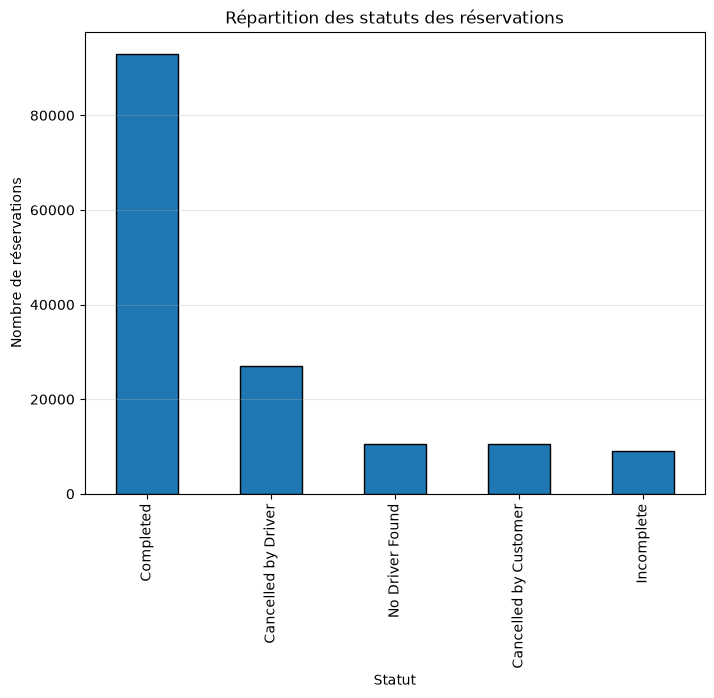

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

df["Booking Status"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Répartition des statuts des réservations")
plt.xlabel("Statut")
plt.ylabel("Nombre de réservations")
plt.grid(axis="y", alpha=0.3)

plt.show()


### 1. Répartition des statuts de réservation
- Permet d'identifier la proportion de courses terminées, annulées, incomplètes...
- Analyse :
    - taux de réussite
    - taux d'annulation
    - problèmes opérationnels

### vérifier les valeurs aberrantes (outliers)
- Distances négatives,
- Valeurs de réservation négatives,
- Notes hors intervalle (0-5),
- Temps impossibles

In [17]:
# 1. Distances négatives
distance_neg = df[df["Ride Distance"] < 0]
print(f"Distances négatives : {len(distance_neg)}")
print(distance_neg)

# 2. Valeurs de réservation négatives
booking_neg = df[df["Booking Value"] < 0]
print(f"\nValeurs de réservation négatives : {len(booking_neg)}")
print(booking_neg)

# 3. Notes chauffeur hors de l'intervalle [0 ; 5]
driver_rating_out = df[
    (df["Driver Ratings"] < 0) |
    (df["Driver Ratings"] > 5)
]
print(f"\nNotes chauffeur hors intervalle : {len(driver_rating_out)}")
print(driver_rating_out)

# 4. Notes client hors de l'intervalle [0 ; 5]
customer_rating_out = df[
    (df["Customer Rating"] < 0) |
    (df["Customer Rating"] > 5)
]
print(f"\nNotes client hors intervalle : {len(customer_rating_out)}")
print(customer_rating_out)

# 5. Temps d'attribution (VTAT) impossibles
vtat_out = df[df["Avg VTAT"] < 0]
print(f"\nTemps VTAT négatifs : {len(vtat_out)}")
print(vtat_out)

# 6. Temps d'arrivée (CTAT) impossibles
ctat_out = df[df["Avg CTAT"] < 0]
print(f"\nTemps CTAT négatifs : {len(ctat_out)}")
print(ctat_out)

Distances négatives : 0
Empty DataFrame
Columns: [Date, Time, Booking ID, Booking Status, Customer ID, Vehicle Type, Pickup Location, Drop Location, Avg VTAT, Avg CTAT, Cancelled Rides by Customer, Reason for cancelling by Customer, Cancelled Rides by Driver, Driver Cancellation Reason, Incomplete Rides, Incomplete Rides Reason, Booking Value, Ride Distance, Driver Ratings, Customer Rating, Payment Method]
Index: []

[0 rows x 21 columns]

Valeurs de réservation négatives : 0
Empty DataFrame
Columns: [Date, Time, Booking ID, Booking Status, Customer ID, Vehicle Type, Pickup Location, Drop Location, Avg VTAT, Avg CTAT, Cancelled Rides by Customer, Reason for cancelling by Customer, Cancelled Rides by Driver, Driver Cancellation Reason, Incomplete Rides, Incomplete Rides Reason, Booking Value, Ride Distance, Driver Ratings, Customer Rating, Payment Method]
Index: []

[0 rows x 21 columns]

Notes chauffeur hors intervalle : 0
Empty DataFrame
Columns: [Date, Time, Booking ID, Booking Statu

In [18]:
print("Résumé des anomalies")
print("-" * 30)
print(f"Distances négatives          : {len(distance_neg)}")
print(f"Valeurs réservation négatives: {len(booking_neg)}")
print(f"Notes chauffeur invalides    : {len(driver_rating_out)}")
print(f"Notes client invalides       : {len(customer_rating_out)}")
print(f"VTAT négatifs                : {len(vtat_out)}")
print(f"CTAT négatifs                : {len(ctat_out)}")

Résumé des anomalies
------------------------------
Distances négatives          : 0
Valeurs réservation négatives: 0
Notes chauffeur invalides    : 0
Notes client invalides       : 0
VTAT négatifs                : 0
CTAT négatifs                : 0


In [ ]:
# Fonction de détection des valeurs extrêmes (outliers statistiques)
# Les valeurs négatives sont des erreurs de données, mais certaines valeurs très élevées peuvent aussi être des outliers. 
# on pt créer une fonction qui utilise l'intervalle interquartile (IQR) :

def detect_outliers_iqr(dataframe, colonne):
    Q1 = dataframe[colonne].quantile(0.25)
    Q3 = dataframe[colonne].quantile(0.75)
    IQR = Q3 - Q1

    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    outliers = dataframe[
        (dataframe[colonne] < borne_inf) |
        (dataframe[colonne] > borne_sup)
    ]

    print(f"{colonne} : {len(outliers)} valeurs aberrantes")
    return outliers

In [20]:
out_distance = detect_outliers_iqr(df, "Ride Distance")
out_booking = detect_outliers_iqr(df, "Booking Value")
out_vtat = detect_outliers_iqr(df, "Avg VTAT")
out_ctat = detect_outliers_iqr(df, "Avg CTAT")
out_rating = detect_outliers_iqr(df, "Customer Rating")
out_cancelled = detect_outliers_iqr(df, "Cancelled Rides by Customer")
#out_ = detect_outliers_iqr(df, "")
#out_ = detect_outliers_iqr(df, "")

Ride Distance : 0 valeurs aberrantes
Booking Value : 3435 valeurs aberrantes
Avg VTAT : 0 valeurs aberrantes
Avg CTAT : 0 valeurs aberrantes
Customer Rating : 3257 valeurs aberrantes
Cancelled Rides by Customer : 0 valeurs aberrantes


In [ ]:
# Des montants exceptionnellement élevés dans la colonne Booking Value ne doivent pas être supprimés automatiquement. 
# Ils peuvent représenter 
#   - soit des erreurs de saisie, 
#   - soit des courses légitimes à forte valeur. Voici une démarche d'analyse.

# trouver les lignes concernées
Q1 = df["Booking Value"].quantile(0.25)
Q3 = df["Booking Value"].quantile(0.75)
IQR = Q3 - Q1

borne_sup = Q3 + 1.5 * IQR

outliers = df[df["Booking Value"] > borne_sup]

print(outliers)

              Date      Time  Booking ID Booking Status Customer ID  \
29      2024-11-03  12:24:59  CNR8779845      Completed  CID7444351   
50      2024-05-04  21:26:59  CNR1572483     Incomplete  CID6059557   
80      2024-02-10  09:17:39  CNR4487090      Completed  CID1210782   
91      2024-09-30  12:34:51  CNR7449144      Completed  CID8609350   
212     2024-06-15  19:12:37  CNR5269641      Completed  CID8225890   
...            ...       ...         ...            ...         ...   
149665  2024-09-14  18:50:55  CNR9542376      Completed  CID6034831   
149695  2024-12-22  21:51:22  CNR8559777      Completed  CID2280669   
149898  2024-01-14  06:24:13  CNR6646948      Completed  CID9300170   
149942  2024-10-19  21:11:41  CNR1354727      Completed  CID3182638   
149966  2024-08-03  12:37:00  CNR2520587      Completed  CID5647520   

         Vehicle Type      Pickup Location        Drop Location  Avg VTAT  \
29               Auto  Faridabad Sector 15        Malviya Nagar       

In [ ]:
# Vérifier s'ils sont cohérents
# on compare les montants avec :
#     - la distance (Ride Distance)
#     - le type de véhicule (Vehicle Type)
#     - le statut de réservation (Booking Status)
#     - les lieux de départ et d'arrivée
outliers[[
    "Booking Value",
    "Ride Distance",
    "Vehicle Type",
    "Booking Status"
]].sort_values("Booking Value", ascending=False)

# Si une réservation de 2 000 correspond à une distance de 5 km, il y a probablement une erreur.

,Booking Value,Ride Distance,Vehicle Type,Booking Status
7450,4277.0,8.66,Go Mini,Completed
83506,4228.0,11.73,Bike,Completed
2731,4220.0,10.11,Auto,Completed
90418,4202.0,4.62,Auto,Completed
7116,4133.0,25.66,Go Mini,Completed
...,...,...,...,...
24505,1372.0,44.81,Premier Sedan,Completed
9040,1372.0,21.64,Uber XL,Completed
56677,1372.0,18.44,Auto,Completed
97307,1372.0,49.25,Go Sedan,Completed


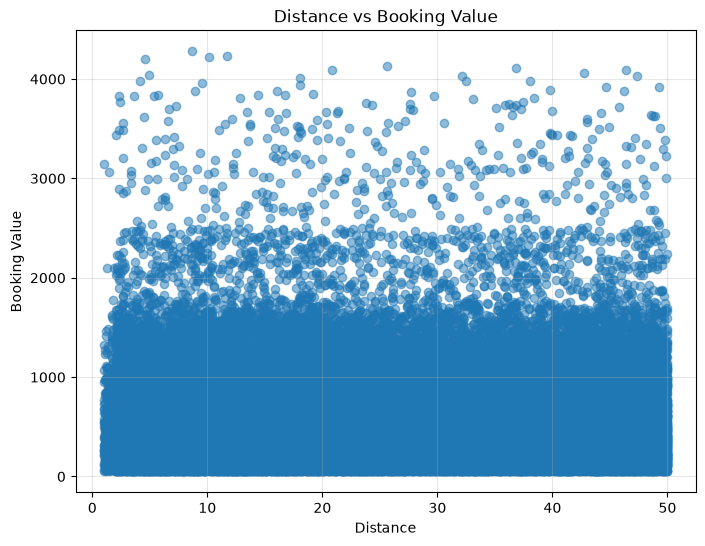

In [ ]:
# Visualiser la relation Distance / Prix
plt.figure(figsize=(8,6))

plt.scatter(
    df["Ride Distance"],
    df["Booking Value"],
    alpha=0.5
)

plt.xlabel("Distance")
plt.ylabel("Booking Value")
plt.title("Distance vs Booking Value")

plt.grid(alpha=0.3)

plt.show()
# Les points très éloignés des autres sont à examiner

In [24]:
print(
    outliers[
        [
            "Booking ID",
            "Booking Value",
            "Ride Distance",
            "Vehicle Type",
            "Booking Status",
            "Pickup Location",
            "Drop Location"
        ]
    ].sort_values("Booking Value", ascending=False)
)

       Booking ID  Booking Value  Ride Distance   Vehicle Type Booking Status  \
7450   CNR7954315         4277.0           8.66        Go Mini      Completed   
83506  CNR1798489         4228.0          11.73           Bike      Completed   
2731   CNR8487909         4220.0          10.11           Auto      Completed   
90418  CNR5182516         4202.0           4.62           Auto      Completed   
7116   CNR7356012         4133.0          25.66        Go Mini      Completed   
...           ...            ...            ...            ...            ...   
24505  CNR3728835         1372.0          44.81  Premier Sedan      Completed   
9040   CNR3347914         1372.0          21.64        Uber XL      Completed   
56677  CNR2356527         1372.0          18.44           Auto      Completed   
97307  CNR8989434         1372.0          49.25       Go Sedan      Completed   
99411  CNR8902870         1372.0          49.67           Bike      Completed   

      Pickup Location      

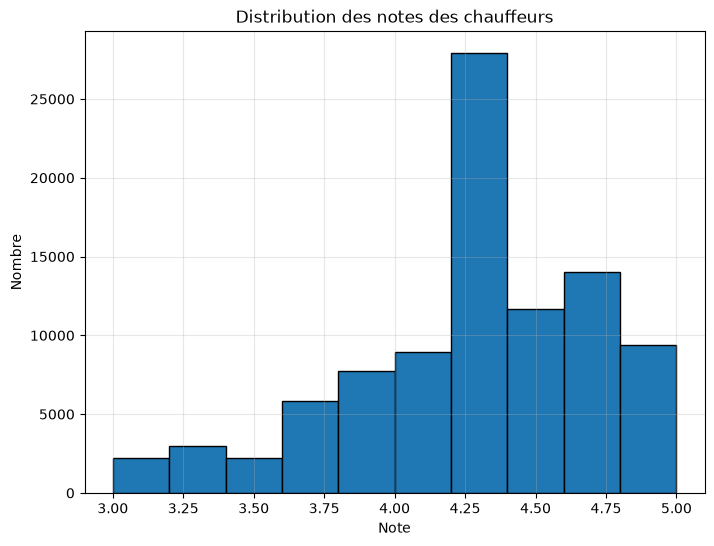

In [25]:
plt.figure(figsize=(8,6))

plt.hist(
    df["Driver Ratings"].dropna(),
    bins=10,
    edgecolor="black"
)

plt.title("Distribution des notes des chauffeurs")
plt.xlabel("Note")
plt.ylabel("Nombre")

plt.grid(alpha=0.3)

plt.show()

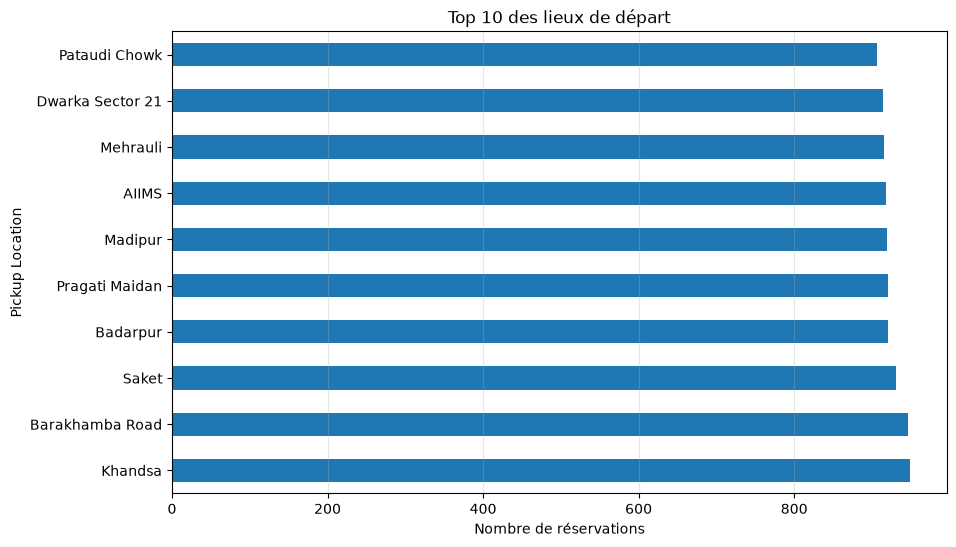

In [ ]:
# Top 10 des lieux de départ
plt.figure(figsize=(10,6))

df["Pickup Location"] \
    .value_counts() \
    .head(10) \
    .plot(kind="barh")

plt.title("Top 10 des lieux de départ")
plt.xlabel("Nombre de réservations")

plt.grid(axis="x", alpha=0.3)

plt.show()

# Positionner davantage de chauffeurs dans les zones les plus demandées

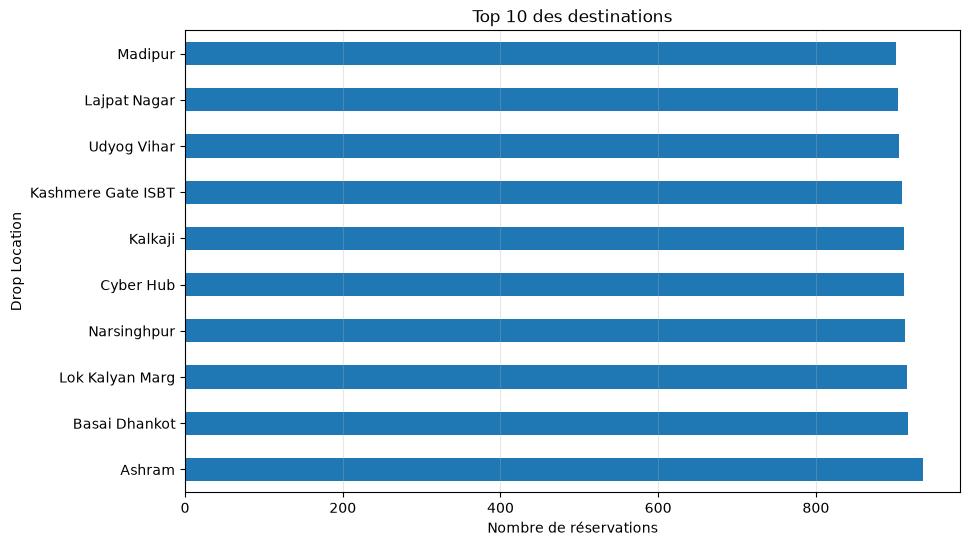

In [ ]:
plt.figure(figsize=(10,6))

df["Drop Location"] \
    .value_counts() \
    .head(10) \
    .plot(kind="barh")

plt.title("Top 10 des destinations")
plt.xlabel("Nombre de réservations")

plt.grid(axis="x", alpha=0.3)

plt.show()

# Décision possible: Identifier les principaux flux de déplacement

### Nouvelles colonnes

#### Jour de la semaine

- Identifier les jours les plus chargés

#### Mois

- Permet d'étudier la saisonnalité

#### Prix par kilomètre

- Permet de détecter :

    - anomalies tarifaires
    - courses premium
    - différences entre véhicules

#### Temps total d'attente

- utile pour mesurer la qualité de service

#### 

In [30]:
df["Date"] = pd.to_datetime(df["Date"])

df["Weekday"] = df["Date"].dt.day_name()

In [32]:
df["Month"] = df["Date"].dt.month_name()

In [33]:
# réservations rentables
df["High Value"] = df["Booking Value"] > df["Booking Value"].median()

In [37]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

C:\Users\Data404\AppData\Local\Temp\ipykernel_11636\816105062.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


In [38]:
def periode(h):
    if h < 6:
        return "Nuit"
    elif h < 12:
        return "Matin"
    elif h < 18:
        return "Après-midi"
    else:
        return "Soir"

df["Period"] = df["Hour"].apply(periode)

In [39]:
df["Price_per_km"] = (
    df["Booking Value"] /
    df["Ride Distance"]
)
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Price_per_km,Weekday,Month,High Value,Hour,Period
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Saturday,March,False,12,Après-midi
1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,5.73,NaN,NaN,UPI,41.361257,Friday,November,False,18,Soir
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,13.58,4.9,4.9,Debit Card,46.170839,Friday,August,True,8,Matin
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,34.02,4.6,5.0,UPI,12.228101,Monday,October,True,17,Après-midi
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,48.21,4.1,4.3,UPI,15.287285,Monday,September,True,22,Soir
